# MF vs NN Validation

Compare mean-field (MF) ODE simulation against neural-network (NN) spike data from `test_0`.

This notebook:
1. Loads NN spike data from HDF5
2. Reconstructs the driving input protocol
3. Runs the MF ODE simulation
4. Plots side-by-side comparison
5. Prints summary statistics

In [1]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from ntmf.config import (
    adding_K_params,
    get_params_model_SI,
    load_spike_data,
)
from ntmf.meanfield import simulate_MF_FS_RS_ode
from ntmf.validation import (
    build_driving_input_from_hdf5,
    build_mf_network_config,
    compare_mf_nn,
    compute_nn_population_rates,
)

plt.rcParams.update({"font.size": 11, "figure.dpi": 100})

## 1. Load NN Spike Data

In [2]:
# Notebook runs from transfer_function/validation/, so project root is 2 dirs up
project_root = Path(".").resolve().parent.parent

hdf5_path = project_root / "neural_network_simulation" / "simulations" / "test_0" / "spikes_data.h5"
nn_data = load_spike_data(hdf5_path)

sim_duration = nn_data["sim_duration"]
N_FS = int(nn_data["network_composition"]["num_FS_neurons"])
N_RS = int(nn_data["network_composition"]["num_RS_neurons"])

print(f"Simulation duration: {sim_duration} s")
print(f"N_FS = {N_FS}, N_RS = {N_RS}")
for pop in ("FS", "RS"):
    n_spikes = len(nn_data["spikes"][pop]["t"])
    print(f"{pop}: {n_spikes} spikes")

print()
print("External input protocol:")
for k, v in nn_data["external_input"].items():
    print(f"  {k}: {v}")

Simulation duration: 10.0 s
N_FS = 2000, N_RS = 8000
FS: 71285 spikes
RS: 94722 spikes

External input protocol:
  exc_input_FS_freq_Hz: 5.0
  exc_input_FS_time_s: [1. 2.]
  exc_input_RS_freq_Hz: 3.0
  exc_input_RS_time_s: [3. 4.]
  inh_input_FS_freq_Hz: 10.0
  inh_input_FS_time_s: [5. 6.]
  inh_input_RS_freq_Hz: 30.0
  inh_input_RS_time_s: [7. 8.]


## 2. Compute Binned NN Population Rates

In [3]:
bin_size = 0.1  # 100 ms bins
nn_rates = compute_nn_population_rates(
    nn_data, N_FS=N_FS, N_RS=N_RS,
    sim_duration=sim_duration, bin_size=bin_size,
)
nn_bins = nn_rates['FS'][0]  # same for both populations
print(f"{len(nn_bins)} bins of {bin_size*1000:.0f} ms")
print(f'FS mean rate: {np.mean(nn_rates["FS"][1]):.2f} Hz')
print(f'RS mean rate: {np.mean(nn_rates["RS"][1]):.2f} Hz')

100 bins of 100 ms
FS mean rate: 3.56 Hz
RS mean rate: 1.18 Hz


## 3. Build MF Configuration and Driving Input

In [4]:
# Network config augmented with Q_e/Q_i
mf_config = build_mf_network_config(
    str(project_root / "config" / "network_config_file_v0.json"),
    Q_e_nS=1.5, Q_i_nS=5.0,
)

# Neuron model params (SI units)
model_dir = project_root / "neuron_models" / "AdEx"
params_FS = get_params_model_SI("FS", model_dir / "FS.json")
params_RS = get_params_model_SI("RS", model_dir / "RS.json")
params_FS = adding_K_params(params_FS.copy(), mf_config)
params_RS = adding_K_params(params_RS.copy(), mf_config)

# TF fitting params (best from validation set)
val_dir = project_root / "transfer_function" / "validation"
with open(val_dir / "FS_MF_params.json") as f:
    fs_fit = json.load(f)
with open(val_dir / "RS_MF_params.json") as f:
    rs_fit = json.load(f)

alphas = {"FS": fs_fit[0]["alpha"], "RS": rs_fit[0]["alpha"]}
poly_params = {
    "FS": fs_fit[0]["polynomial_params"],
    "RS": rs_fit[0]["polynomial_params"],
}

print(f'FS: alpha={alphas["FS"]:.3f}, mean_error={fs_fit[0]["mean_error"]:.2f}')
print(f'RS: alpha={alphas["RS"]:.3f}, mean_error={rs_fit[0]["mean_error"]:.2f}')

FS: alpha=1.165, mean_error=6.69
RS: alpha=1.170, mean_error=0.25


## 4. Run MF ODE Simulation

In [5]:
dt = 1e-3  # 1 ms
time = np.arange(0, sim_duration, dt)

driving_input = build_driving_input_from_hdf5(
    str(hdf5_path), time=time, network_config=mf_config,
)

mf_rates = simulate_MF_FS_RS_ode(
    time=time,
    neuron_models=["FS", "RS"],
    params={"FS": params_FS, "RS": params_RS},
    poly_params=poly_params,
    alphas=alphas,
    network_config=mf_config,
    driving_input=driving_input,
    tau_f=0.01,
)

print("MF simulation complete.")
print(f'FS steady-state (last 100ms): {np.mean(mf_rates["FS"][-100:]):.2f} Hz')
print(f'RS steady-state (last 100ms): {np.mean(mf_rates["RS"][-100:]):.2f} Hz')

MF simulation complete.
FS steady-state (last 100ms): 3.57 Hz
RS steady-state (last 100ms): 1.81 Hz


## 5. Comparison Statistics

In [6]:
stats = compare_mf_nn(mf_rates, time, nn_rates)

print("=" * 50)
print("MF vs NN Validation Summary")
print("=" * 50)
header = f"{"":20s} {"FS":>10s} {"RS":>10s}"
print(header)
print("-" * 42)
print(f'{"RMSE (Hz)":20s} {stats["rmse_FS"]:10.3f} {stats["rmse_RS"]:10.3f}')
print(f'{"Pearson r":20s} {stats["corr_FS"]:10.3f} {stats["corr_RS"]:10.3f}')
print()

# Background period [0.2, 1.0) s
mask_bg = (nn_bins >= 0.2) & (nn_bins < 1.0)
for pop in ("FS", "RS"):
    nn_bg = np.mean(nn_rates[pop][1][mask_bg])
    mask_mf = (time >= 0.2) & (time < 1.0)
    mf_bg = np.mean(mf_rates[pop][mask_mf])
    ratio = max(mf_bg, nn_bg) / max(min(mf_bg, nn_bg), 1e-12) if nn_bg > 0.1 else float("nan")
    print(f'{pop} background: MF={mf_bg:.2f} Hz, NN={nn_bg:.2f} Hz, ratio={ratio:.2f}')

MF vs NN Validation Summary
                             FS         RS
------------------------------------------
RMSE (Hz)                 5.738      3.593
Pearson r                 0.824      0.503

FS background: MF=3.57 Hz, NN=0.00 Hz, ratio=nan
RS background: MF=1.81 Hz, NN=0.00 Hz, ratio=nan


## 6. Side-by-Side Plots

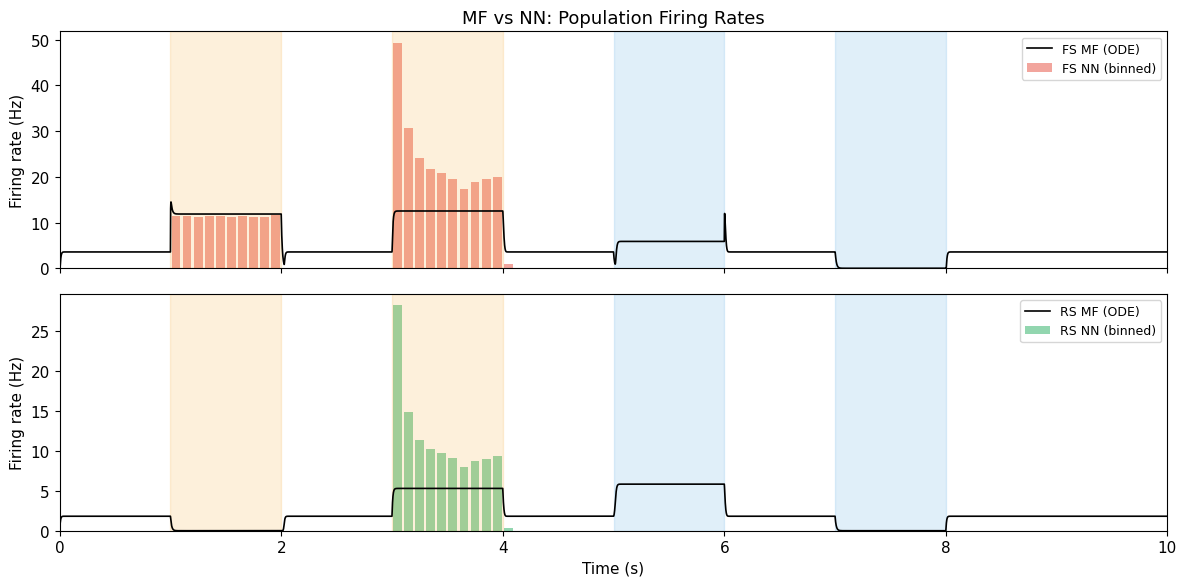

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

bar_width = bin_size * 0.8
colors = {"FS": "#e74c3c", "RS": "#27ae60"}

for idx, pop in enumerate(("FS", "RS")):
    ax = axes[idx]

    # NN binned rates as bars
    ax.bar(nn_bins, nn_rates[pop][1], width=bar_width, alpha=0.5,
           color=colors[pop], label=f"{pop} NN (binned)", edgecolor="none")

    # MF rate as line
    ax.plot(time, mf_rates[pop], color="black", lw=1.2,
            label=f"{pop} MF (ODE)")

    ax.set_ylabel("Firing rate (Hz)")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_xlim(0, sim_duration)

    # Shade stimulus periods
    stimulus_shades = [
        (1, 2, "#f39c12", 0.15, "exc->FS"),
        (3, 4, "#f39c12", 0.15, "exc->RS"),
        (5, 6, "#3498db", 0.15, "inh->FS"),
        (7, 8, "#3498db", 0.15, "inh->RS"),
    ]
    for t0, t1, c, a, lbl in stimulus_shades:
        if idx == 0:
            ax.axvspan(t0, t1, color=c, alpha=a, label=lbl)
        else:
            ax.axvspan(t0, t1, color=c, alpha=a)

axes[0].set_title("MF vs NN: Population Firing Rates", fontsize=13)
axes[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig("MF_vs_NN_comparison.png", dpi=150, bbox_inches="tight")
plt.show()